<font size="5"><b>1.Initial Setup & Data Loading</b></font>


In [ ]:
import kagglehub
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

# Set visualisation style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


In [ ]:
# Download latest version
path = kagglehub.dataset_download("alanvourch/tmdb-movies-daily-updates")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\USER\.cache\kagglehub\datasets\alanvourch\tmdb-movies-daily-updates\versions\839


In [ ]:
# List all files in the downloaded path
files = os.listdir(path)
print("Files in dataset:", files)

Files in dataset: ['TMDB_all_movies.csv']


In [ ]:
# Join the directory path with the specific filename
file_path = os.path.join(path, 'TMDB_all_movies.csv')

# Load the data into a DataFrame
df = pd.read_csv(file_path)


<font size="5"><b>2.DATA EXPLORATION</b></font>

<font size="3"><b>2.1 Basic statistics</b></font>

In [ ]:
# 2.1 Basic statistics
print(f"Dataset Shape: {df.shape}")
print(f"\nMissing Values:\n{df.isnull().sum()}")
print(f"\nMissing Value Percentage:\n{(df.isnull().sum()/len(df)*100).sort_values(ascending=False)}")

Dataset Shape: (1182170, 28)

Missing Values:
id                               0
title                            9
vote_average                     0
vote_count                       0
status                           0
release_date                124046
revenue                          0
runtime                          0
budget                           0
imdb_id                     520024
original_language                0
original_title                   8
overview                    180786
popularity                       0
tagline                    1003249
genres                      318517
production_companies        612987
production_countries        438624
spoken_languages            430930
cast                        375545
director                    191047
director_of_photography     864738
writers                     584136
producers                   778873
music_composer             1048291
imdb_rating                 716023
imdb_votes                  716023
poster_pa

<font size="3"><b>2.2 Statistical summary</b></font>

In [ ]:
# 2.2 Statistical summary
df.describe()

,id,vote_average,vote_count,revenue,runtime,budget,popularity,imdb_rating,imdb_votes
count,1.182170e+06,1.182170e+06,1.182170e+06,1.182170e+06,1.182170e+06,1.182170e+06,1.182170e+06,466147.000000,4.661470e+05
mean,8.462180e+05,1.989789e+00,2.253716e+01,6.998900e+05,4.407424e+01,2.779305e+05,7.878896e-01,6.249960,2.804404e+03
std,4.761907e+05,3.050971e+00,3.650096e+02,1.685414e+07,5.480545e+01,4.659681e+06,2.038156e+00,1.325083,3.240785e+04
min,2.000000e+00,0.000000e+00,0.000000e+00,-1.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,5.000000e+00
25%,4.386092e+05,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+00,0.000000e+00,1.045000e-01,5.500000,2.000000e+01
50%,8.327040e+05,0.000000e+00,0.000000e+00,0.000000e+00,2.100000e+01,0.000000e+00,6.000000e-01,6.400000,5.900000e+01
75%,1.258374e+06,5.000000e+00,1.000000e+00,0.000000e+00,8.500000e+01,0.000000e+00,8.940000e-01,7.100000,2.630000e+02
max,1.670439e+06,1.000000e+01,3.936500e+04,2.923706e+09,1.440000e+04,4.899000e+08,8.626643e+02,10.000000,3.178259e+06


<font size="3"><b>2.3 Check for duplicates</b></font>

In [ ]:
# 2.3 Check for duplicates
print(f"Duplicate rows: {df.duplicated().sum()}")

Duplicate rows: 0


<font size="3"><b>2.4 Sample data</b></font>

In [ ]:
# 2.4 Sample data
df.head(5)

,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,...,spoken_languages,cast,director,director_of_photography,writers,producers,music_composer,imdb_rating,imdb_votes,poster_path
0,2,Ariel,7.106,371.0,Released,1988-10-21,0.0,73.0,0.0,tt0094675,...,suomi,"Kari Helaseppä, Jaakko Talaskivi, Mikko Remes,...",Aki Kaurismäki,Timo Salminen,Aki Kaurismäki,Aki Kaurismäki,NaN,7.4,9721.0,/ojDg0PGvs6R9xYFodRct2kdI6wC.jpg
1,3,Shadows in Paradise,7.300,435.0,Released,1986-10-17,0.0,74.0,0.0,tt0092149,...,"svenska, suomi, English","Ari Korhonen, Mari Rantasila, Erkki Rissanen, ...",Aki Kaurismäki,Timo Salminen,Aki Kaurismäki,Mika Kaurismäki,NaN,7.4,8606.0,/nj01hspawPof0mJmlgfjuLyJuRN.jpg
2,5,Four Rooms,5.900,2819.0,Released,1995-12-09,4257354.0,98.0,4000000.0,tt0113101,...,English,"Sammi Davis, Marc Lawrence, Alicia Witt, Madon...","Robert Rodriguez, Allison Anders, Quentin Tara...","Rodrigo García, Guillermo Navarro, Phil Parmet...","Allison Anders, Robert Rodriguez, Alexandre Ro...","Quentin Tarantino, Alexandre Rockwell, Lawrenc...",Combustible Edison,6.7,116790.0,/75aHn1NOYXh4M7L5shoeQ6NGykP.jpg
3,6,Judgment Night,6.500,369.0,Released,1993-10-15,12136938.0,109.0,21000000.0,tt0107286,...,English,"Nigel Gibbs, Lauren Robinson, Galyn Görg, Lyde...",Stephen Hopkins,Peter Levy,"Lewis Colick, Jere Cunningham","Gene Levy, Marilyn Vance, Lloyd Segan",Alan Silvestri,6.6,21014.0,/3rvvpS9YPM5HB2f4HYiNiJVtdam.jpg
4,8,Life in Loops (A Megacities RMX),7.200,30.0,Released,2006-01-01,0.0,80.0,42000.0,tt0825671,...,"English, हिन्दी, 日本語, Pусский, Español",NaN,Timo Novotny,Wolfgang Thaler,"Timo Novotny, Michael Glawogger","Timo Novotny, Ulrich Gehmacher",NaN,8.1,285.0,/7ln81BRnPR2wqxuITZxEciCe1lc.jpg


<font size="5"><b>3. Data Cleaning</b></font>

<font size="3"><b>3.1 Handling Missing Data</b></font>

In [ ]:
# ============================================
# STEP 1: STRICT CLEANING (High Quality)
# ============================================

# 1. Standardize column names
df.columns = df.columns.str.lower().str.strip()

# 2. Drop unnecessary columns
cols_to_drop = ['imdb_id', 'overview', 'music_composer', 'tagline', 
                'director_of_photography', 'producers', 'roi']
df.drop(columns=cols_to_drop, errors='ignore', inplace=True)

# 3. CRITICAL FIX: Treat 0 as Missing for Financial/Runtime data
# Your dataset likely uses 0 instead of NaN for missing values.
# We must convert 0 to NaN so we can drop these rows.
zero_as_missing = ['budget', 'revenue', 'runtime']
for col in zero_as_missing:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)

# 4. DROP rows with missing critical data
# This removes the "fake" imputed rows from your analysis.
# You will lose some data, but what remains will be REAL.
df.dropna(subset=['budget', 'revenue', 'runtime'], inplace=True)
print(f"🗑️ Dropped rows with missing Budget/Revenue/Runtime.")
print(f"✅ Remaining rows: {len(df):,}")

# 5. Impute remaining numerical columns (Votes/Rating)
# These are less critical, so median imputation is acceptable here.
num_cols_to_impute = ['imdb_votes', 'imdb_rating', 'vote_average', 'popularity']
for col in num_cols_to_impute:
    if col in df.columns:
        # Replace 0 with NaN for vote_average (0 rating is impossible)
        if col == 'vote_average':
            df[col] = df[col].replace(0, np.nan)
        
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)

# 6. Fill categorical
cat_cols = ['production_companies', 'writers', 'spoken_languages', 
            'production_countries', 'cast', 'genres', 'poster_path', 
            'director', 'title', 'original_title']
for col in cat_cols:
    if col in df.columns:
        df[col].fillna('Unknown', inplace=True)

# 7. Drop missing release dates
if 'release_date' in df.columns:
    df.dropna(subset=['release_date'], inplace=True)

print(f"\n✅ Cleaning complete. Final shape: {df.shape}")

# ============================================
# STEP 2: LOG TRANSFORMATION
# ============================================
log_transform_cols = ['budget', 'revenue', 'popularity', 'runtime', 'imdb_votes']

for col in log_transform_cols:
    if col in df.columns:
        df[f'{col}_log'] = np.log1p(df[col])
        print(f"✓ Created '{col}_log'")



🗑️ Dropped rows with missing Budget/Revenue/Runtime.
✅ Remaining rows: 15,187

✅ Cleaning complete. Final shape: (15187, 32)
✓ Created 'budget_log'
✓ Created 'revenue_log'
✓ Created 'popularity_log'
✓ Created 'runtime_log'
✓ Created 'imdb_votes_log'


<font size="3"><b>3.2 Convert date column</b></font>

In [ ]:
# 3.2 Convert date column
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

<font size="3"><b>3.3 Create derived columns</b></font>

In [ ]:
# 3.3 Create derived columns
df['profit'] = df['revenue'] - df['budget']
df['roi'] = np.where(df['budget'] > 0, (df['profit'] / df['budget']) * 100, 0)  # Return on Investment
df['vote_quality'] = df['vote_average'] * np.log1p(df['vote_count'])  # Weighted rating

<font size="5"><b>4. Univariate Analysis (One Variable at a Time)</b></font>

<font size="3"><b>4.1 Distribution of numerical columns</b></font>

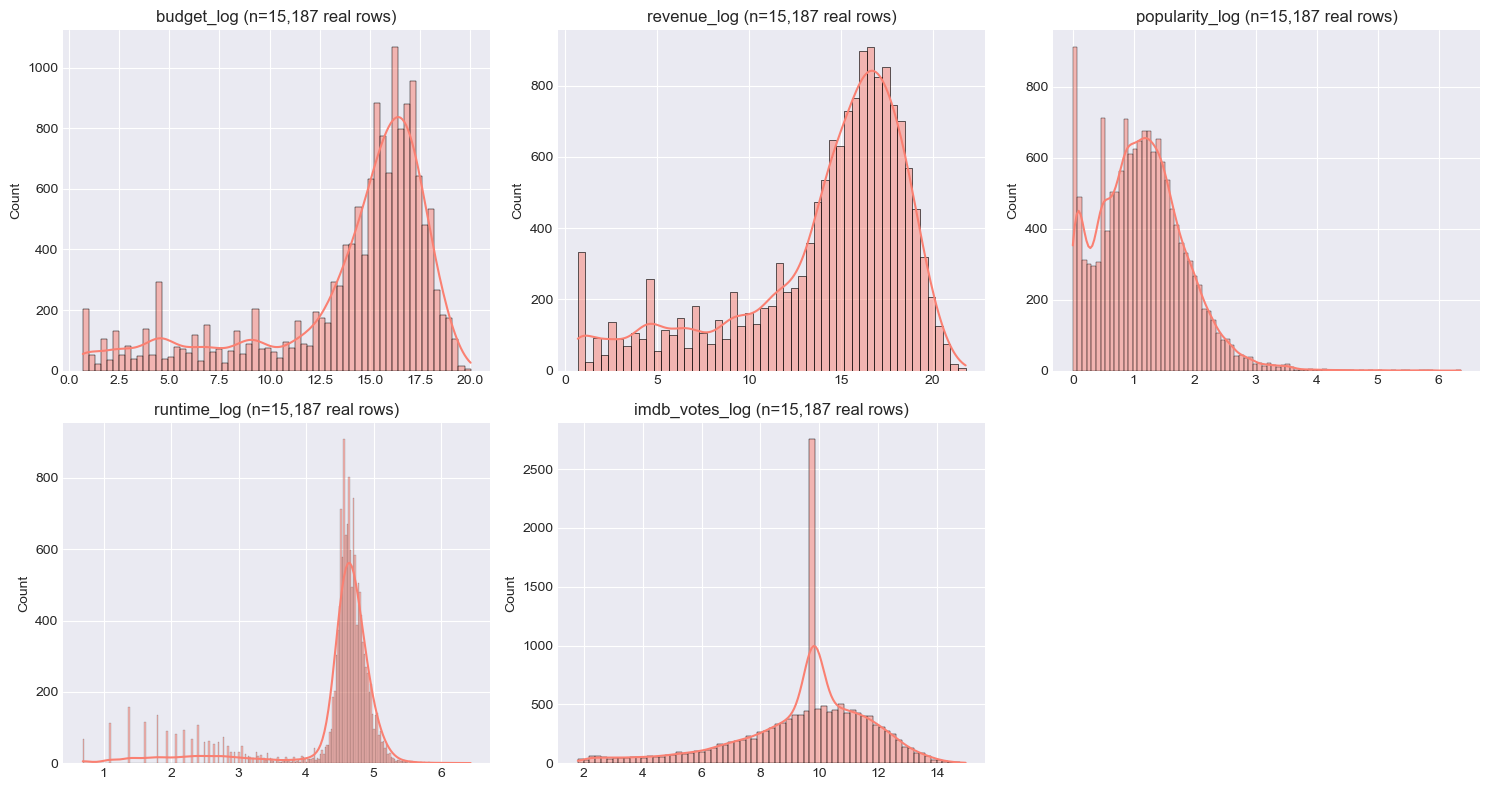

In [ ]:
# Visualize log-transformed columns
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(log_transform_cols):
    log_col = f'{col}_log'
    if log_col in df.columns:
        sns.histplot(df[log_col].dropna(), kde=True, ax=axes[i], color='salmon')
        axes[i].set_title(f'{log_col} (n={len(df):,} real rows)')
        axes[i].set_xlabel('')
    else:
        axes[i].axis('off')

# Hide the 6th unused subplot
axes[5].axis('off')

plt.tight_layout()
plt.show()


<font size="3"><b>4.2 Box plots to detect outliers</b></font>

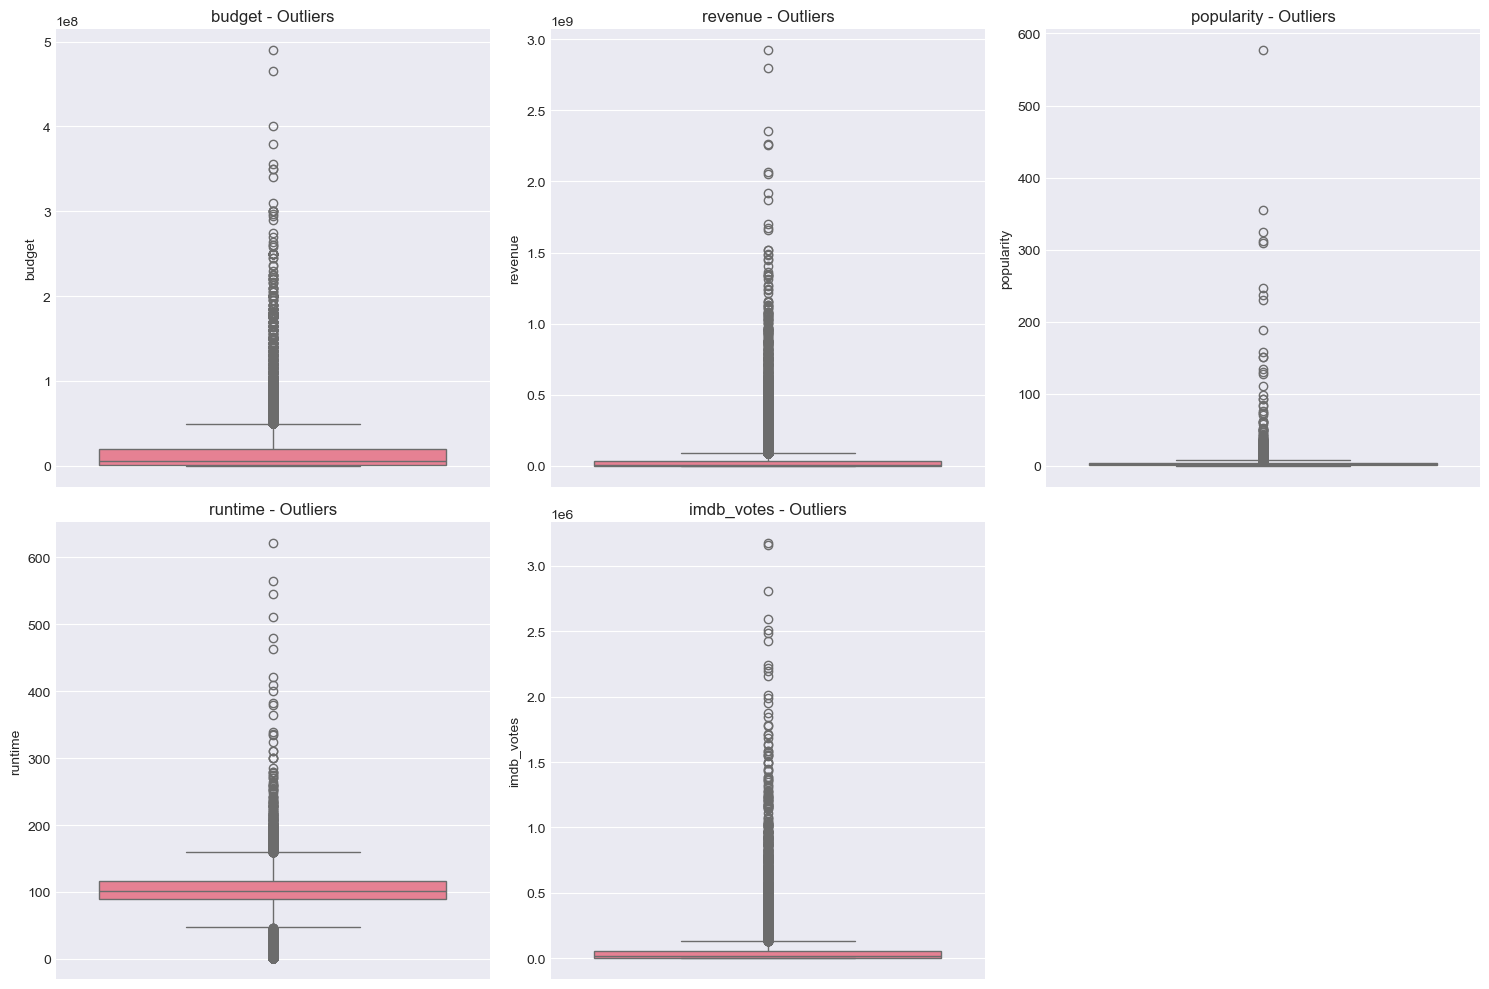

In [ ]:
# 4.2 Box plots to detect outliers
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(log_transform_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'{col} - Outliers')

# Hide the 6th unused subplot
axes[5].axis('off')
    
plt.tight_layout()
plt.show()

<font size="3"><b>4.3 Categorical Variables Analysis</b></font>

<font size="3"><b>4.3.1 Movie Status</b></font>

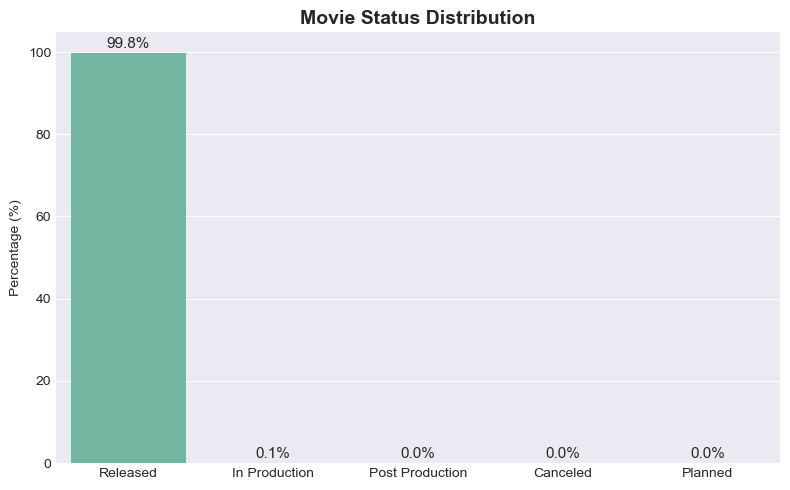

In [ ]:
# Prepare data
status_counts = df['status'].dropna().value_counts()
status_pct = (status_counts / status_counts.sum() * 100).round(1)

# Visualize
fig, ax = plt.subplots(figsize=(8, 5))
bars = sns.barplot(x=status_pct.index, y=status_pct.values, palette='Set2', ax=ax)
ax.set_title('Movie Status Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('')

# Add percentage labels on bars
for bar, pct in zip(bars.patches, status_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f'{pct}%', ha='center', va='bottom', fontsize=11, fontweight='medium')

plt.tight_layout()
plt.show()

<font size="3"><b>4.3.2 Origunal languange</b></font>

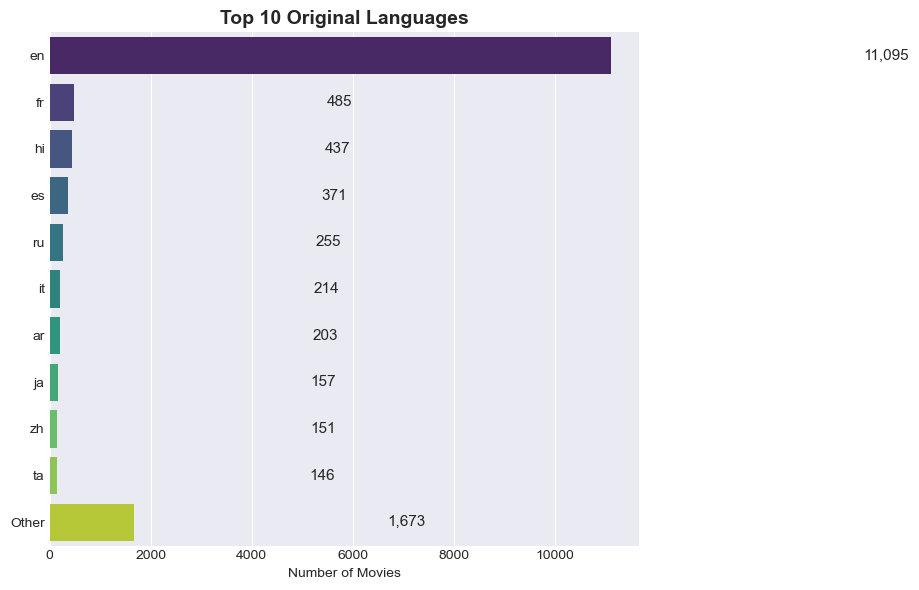

In [ ]:
# Prepare data
lang_counts = df['original_language'].dropna().value_counts()
top_lang = lang_counts.head(10)
other_count = lang_counts[10:].sum()
plot_data = pd.concat([top_lang, pd.Series({'Other': other_count})])

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x=plot_data.values, y=plot_data.index, palette='viridis', ax=ax)
ax.set_title('Top 10 Original Languages', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Movies')
ax.set_ylabel('')

# Add count labels
for bar, count in zip(bars.patches, plot_data.values):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=11, fontweight='medium')

plt.tight_layout()
plt.show()

<font size="3"><b>4.3.3 Genres</b></font>

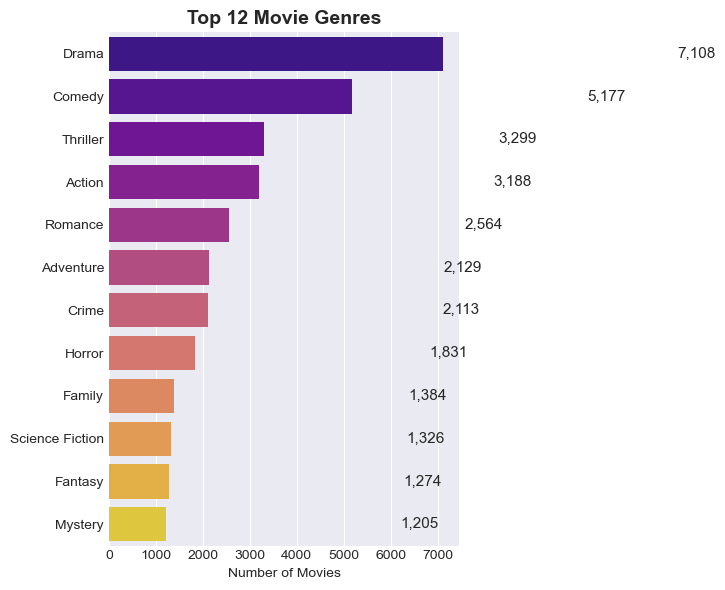

In [ ]:
# Explode comma-separated genres
all_genres = df['genres'].dropna().str.split(',').explode().str.strip()
genre_counts = all_genres.value_counts().head(12)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='plasma', ax=ax)
ax.set_title('Top 12 Movie Genres', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Movies')
ax.set_ylabel('')

for bar, count in zip(bars.patches, genre_counts.values):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=11, fontweight='medium')

plt.tight_layout()
plt.show()

<font size="3"><b>4.3.4 Production Countries</b></font>

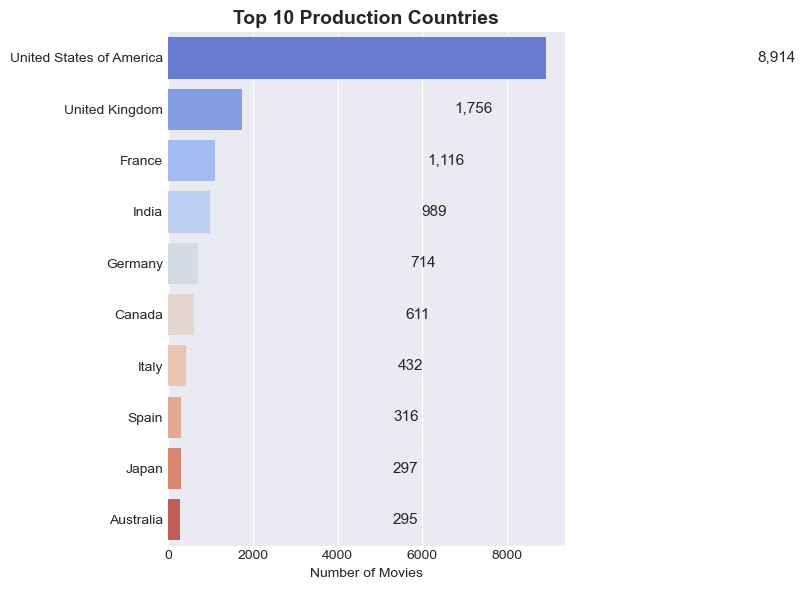

In [ ]:
# Clean & explode (handles string or list-like formats)
countries = df['production_countries'].dropna().astype(str)
countries = countries.str.replace(r"[\[\]\'\"]", "", regex=True).str.split(',').explode().str.strip()
countries = countries[countries.str.len() > 1]  # Remove empty/invalid

# Filter out 'Unknown' values
countries = countries[countries != 'Unknown']

# Calculate Top 10 (now excludes Unknown)
country_counts = countries.value_counts().head(10)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x=country_counts.values, y=country_counts.index, palette='coolwarm', ax=ax)
ax.set_title('Top 10 Production Countries', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Movies')
ax.set_ylabel('')

for bar, count in zip(bars.patches, country_counts.values):
    ax.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, 
            f'{count:,}', va='center', fontsize=11, fontweight='medium')

plt.tight_layout()
plt.show()

# Optional: Report how many were excluded
unknown_count = (countries == 'Unknown').sum()
if unknown_count > 0:
    print(f"📊 Note: Excluded {unknown_count:,} 'Unknown' values from visualization")

<font size="3"><b>4.3.5 Directors</b></font>

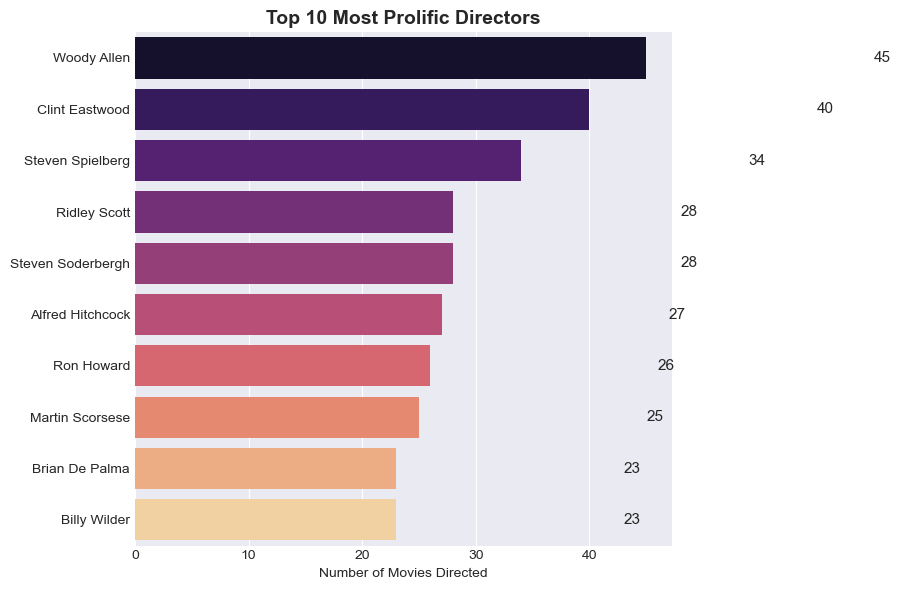

📊 Note: 304 movies (2.0%) have missing director data


In [ ]:
# Filter out 'Unknown' before plotting
director_counts = df['director'].dropna().value_counts()
director_counts = director_counts[director_counts.index != 'Unknown'].head(10)

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
bars = sns.barplot(x=director_counts.values, y=director_counts.index, palette='magma', ax=ax)
ax.set_title('Top 10 Most Prolific Directors', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Movies Directed')
ax.set_ylabel('')

for bar, count in zip(bars.patches, director_counts.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2, 
            f'{count}', va='center', fontsize=11, fontweight='medium')

plt.tight_layout()
plt.show()

# Report the data quality separately
unknown_count = (df['director'] == 'Unknown').sum()
print(f"📊 Note: {unknown_count} movies ({unknown_count/len(df)*100:.1f}%) have missing director data")

<font size="5"><b>5. Bivariate Analysis (Relationships Between Two Variables)</b></font>

<font size="3"><b>5.1 Budget vs Revenue</b></font>

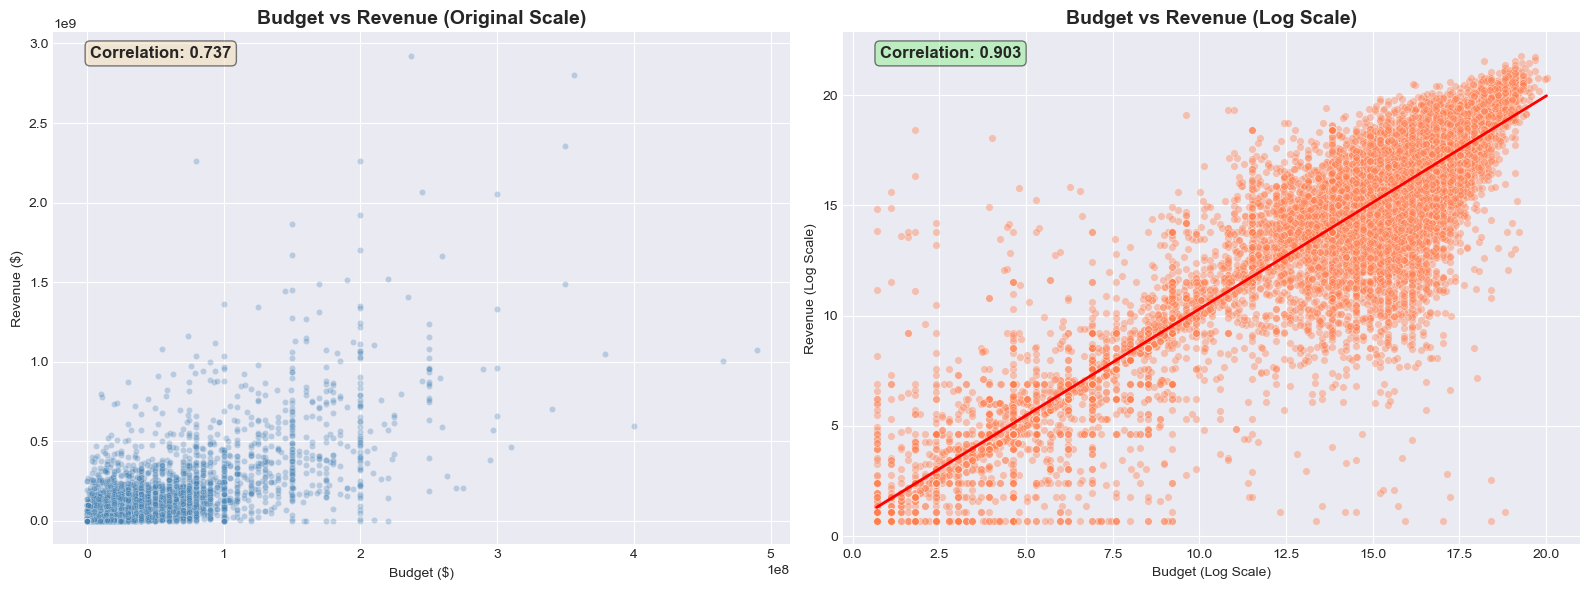

In [ ]:
# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --------------------------------------------
# Plot 1: Original Scale (for context)
# --------------------------------------------
sns.scatterplot(data=df, x='budget', y='revenue', 
                alpha=0.3, s=20, color='steelblue', ax=axes[0])
axes[0].set_title('Budget vs Revenue (Original Scale)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Budget ($)')
axes[0].set_ylabel('Revenue ($)')

# Add correlation coefficient
corr_original = df['budget'].corr(df['revenue'])
axes[0].text(0.05, 0.95, f'Correlation: {corr_original:.3f}', 
             transform=axes[0].transAxes, fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# --------------------------------------------
# Plot 2: Log-Transformed Scale (better visualization)
# --------------------------------------------
sns.scatterplot(data=df, x='budget_log', y='revenue_log', 
                alpha=0.4, s=30, color='coral', ax=axes[1])

# Add regression line
sns.regplot(data=df, x='budget_log', y='revenue_log', 
            scatter=False, color='red', line_kws={'linewidth': 2}, ax=axes[1])

axes[1].set_title('Budget vs Revenue (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Budget (Log Scale)')
axes[1].set_ylabel('Revenue (Log Scale)')

# Add correlation coefficient
corr_log = df['budget_log'].corr(df['revenue_log'])
axes[1].text(0.05, 0.95, f'Correlation: {corr_log:.3f}', 
             transform=axes[1].transAxes, fontsize=12, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.show()



<font size="3"><b>5.2 Runtime vs Rating</b></font>

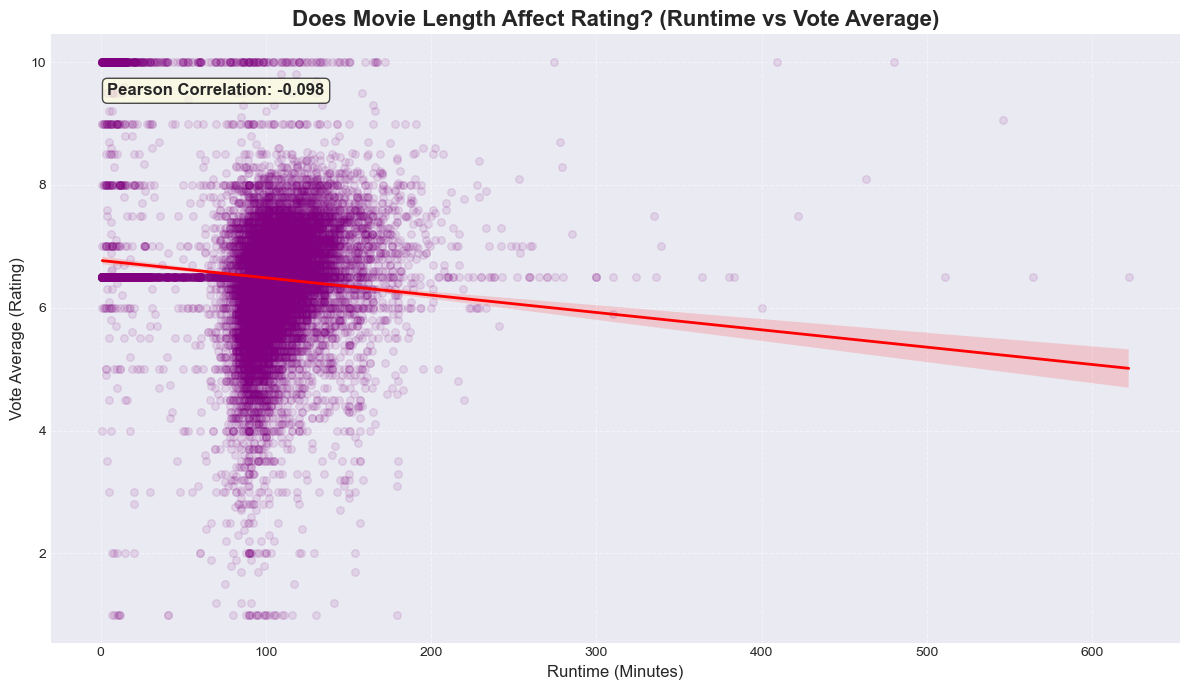

📊 Correlation: -0.0985
💡 Insight: Weak relationship. Movie length likely does not dictate rating.


In [ ]:
# ============================================
# 5.2 Runtime vs Rating (Scatter + Trend Line)
# ============================================

plt.figure(figsize=(12, 7))

# Use regplot to automatically add a regression line (trend line)
sns.regplot(data=df, x='runtime', y='vote_average', 
            scatter_kws={'alpha': 0.1, 's': 30, 'color': 'purple'}, # Make dots transparent
            line_kws={'color': 'red', 'linewidth': 2})              # Make trend line visible

plt.title('Does Movie Length Affect Rating? (Runtime vs Vote Average)', fontsize=16, fontweight='bold')
plt.xlabel('Runtime (Minutes)', fontsize=12)
plt.ylabel('Vote Average (Rating)', fontsize=12)

# Add Correlation Coefficient to the plot
corr = df['runtime'].corr(df['vote_average'])
plt.text(0.05, 0.90, f'Pearson Correlation: {corr:.3f}', 
         transform=plt.gca().transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Print interpretation
print(f"📊 Correlation: {corr:.4f}")
if abs(corr) < 0.1:
    print("💡 Insight: Weak relationship. Movie length likely does not dictate rating.")
elif corr > 0:
    print("💡 Insight: Positive relationship. Longer movies tend to get slightly higher ratings.")
else:
    print("💡 Insight: Negative relationship. Shorter movies tend to get better ratings.")

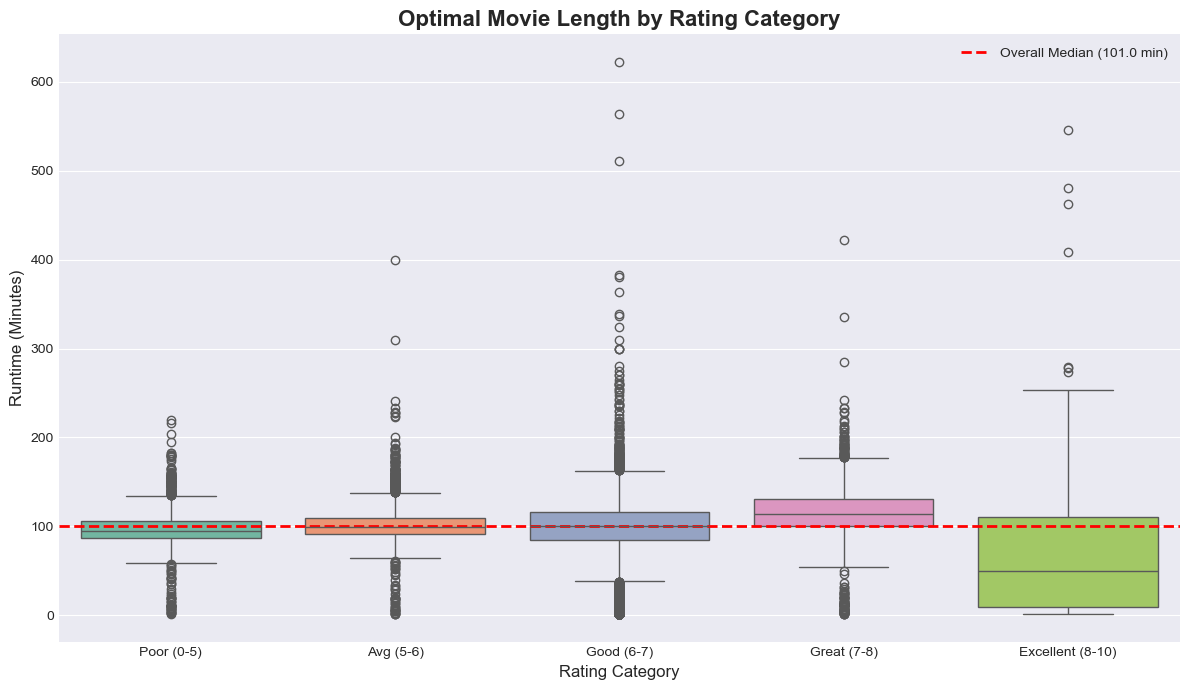

In [ ]:
# ============================================
# 5.2 Runtime vs Rating (Finding the Sweet Spot)
# ============================================

# 1. Bin the ratings to group them (e.g., 0-5, 5-6, 6-7, etc.)
df['rating_bin'] = pd.cut(df['vote_average'], bins=[0, 5, 6, 7, 8, 10], 
                          labels=['Poor (0-5)', 'Avg (5-6)', 'Good (6-7)', 'Great (7-8)', 'Excellent (8-10)'])

# 2. Plot
plt.figure(figsize=(12, 7))
sns.boxplot(data=df, x='rating_bin', y='runtime', palette='Set2')

# 3. Add a line for the overall median runtime to compare
median_runtime = df['runtime'].median()
plt.axhline(y=median_runtime, color='red', linestyle='--', linewidth=2, label=f'Overall Median ({median_runtime} min)')

plt.title('Optimal Movie Length by Rating Category', fontsize=16, fontweight='bold')
plt.xlabel('Rating Category', fontsize=12)
plt.ylabel('Runtime (Minutes)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

# Clean up the helper column
df.drop(columns=['rating_bin'], inplace=True)

<font size="3"><b>5.3 Release Year trends</b></font>

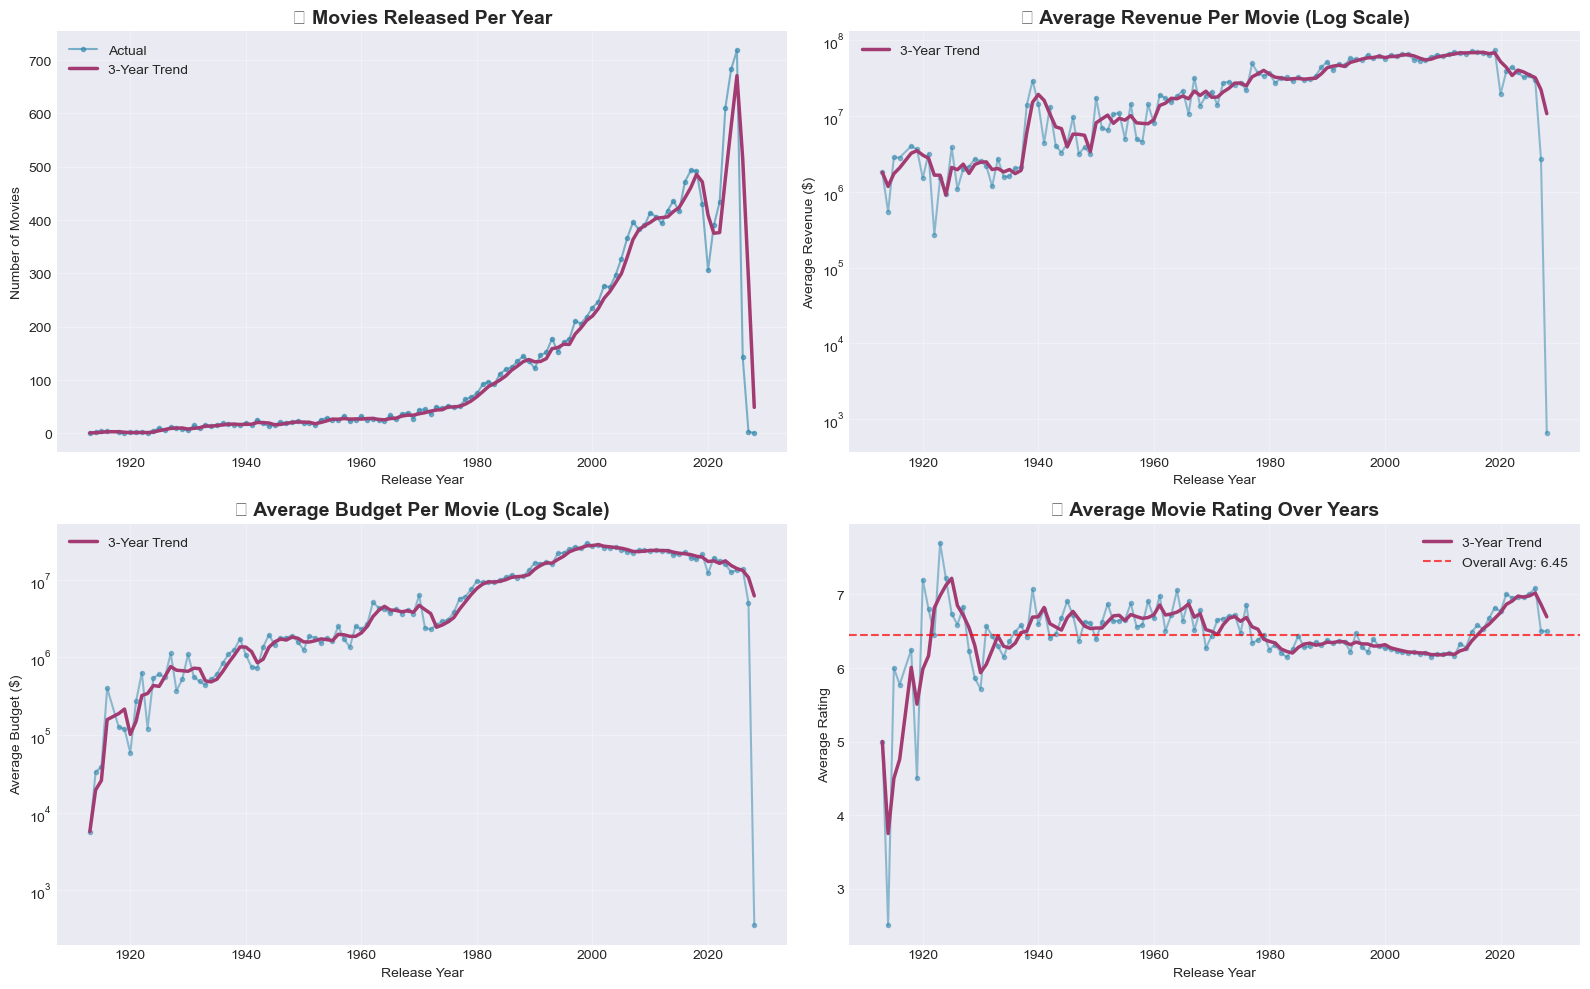

In [ ]:
# ============================================
# 5.3 Release Year Trends Analysis
# ============================================
# Group by year
yearly_stats = df.groupby('release_year').agg({
    'revenue': 'mean',
    'budget': 'mean',
    'vote_average': 'mean',
    'title': 'count',  # Count movies per year
    'popularity': 'mean'
}).rename(columns={'title': 'movie_count'})

# Calculate rolling averages (3-year window) for smoother trends
yearly_stats_smooth = yearly_stats.rolling(window=3, min_periods=1).mean()

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Color palette
color_primary = '#2E86AB'
color_secondary = '#A23B72'
color_accent = '#F18F01'

# ============================================
# Plot 1: Movies Released Per Year
# ============================================
axes[0, 0].plot(yearly_stats.index, yearly_stats['movie_count'], 
                marker='o', markersize=3, alpha=0.6, color=color_primary, label='Actual')
axes[0, 0].plot(yearly_stats_smooth.index, yearly_stats_smooth['movie_count'], 
                linewidth=2.5, color=color_secondary, label='3-Year Trend')
axes[0, 0].set_title('📈 Movies Released Per Year', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Release Year')
axes[0, 0].set_ylabel('Number of Movies')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ============================================
# Plot 2: Average Revenue Over Years (Log Scale)
# ============================================
axes[0, 1].plot(yearly_stats.index, yearly_stats['revenue'], 
                marker='o', markersize=3, alpha=0.5, color=color_primary)
axes[0, 1].plot(yearly_stats_smooth.index, yearly_stats_smooth['revenue'], 
                linewidth=2.5, color=color_secondary, label='3-Year Trend')
axes[0, 1].set_title('💰 Average Revenue Per Movie (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Release Year')
axes[0, 1].set_ylabel('Average Revenue ($)')
axes[0, 1].set_yscale('log')  # Log scale to handle outliers
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ============================================
# Plot 3: Average Budget Over Years (Log Scale)
# ============================================
axes[1, 0].plot(yearly_stats.index, yearly_stats['budget'], 
                marker='o', markersize=3, alpha=0.5, color=color_primary)
axes[1, 0].plot(yearly_stats_smooth.index, yearly_stats_smooth['budget'], 
                linewidth=2.5, color=color_secondary, label='3-Year Trend')
axes[1, 0].set_title('💵 Average Budget Per Movie (Log Scale)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Release Year')
axes[1, 0].set_ylabel('Average Budget ($)')
axes[1, 0].set_yscale('log')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# ============================================
# Plot 4: Average Rating Over Years
# ============================================
axes[1, 1].plot(yearly_stats.index, yearly_stats['vote_average'], 
                marker='o', markersize=3, alpha=0.5, color=color_primary)
axes[1, 1].plot(yearly_stats_smooth.index, yearly_stats_smooth['vote_average'], 
                linewidth=2.5, color=color_secondary, label='3-Year Trend')
axes[1, 1].axhline(y=yearly_stats['vote_average'].mean(), 
                   color='red', linestyle='--', alpha=0.7, label=f"Overall Avg: {yearly_stats['vote_average'].mean():.2f}")
axes[1, 1].set_title('⭐ Average Movie Rating Over Years', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Release Year')
axes[1, 1].set_ylabel('Average Rating')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



<font size="5"><b>6: Multivariate Analysis (Multiple Variables)</b></font>

<font size="3"><b>6.1 Correlation Heatmap</b></font>

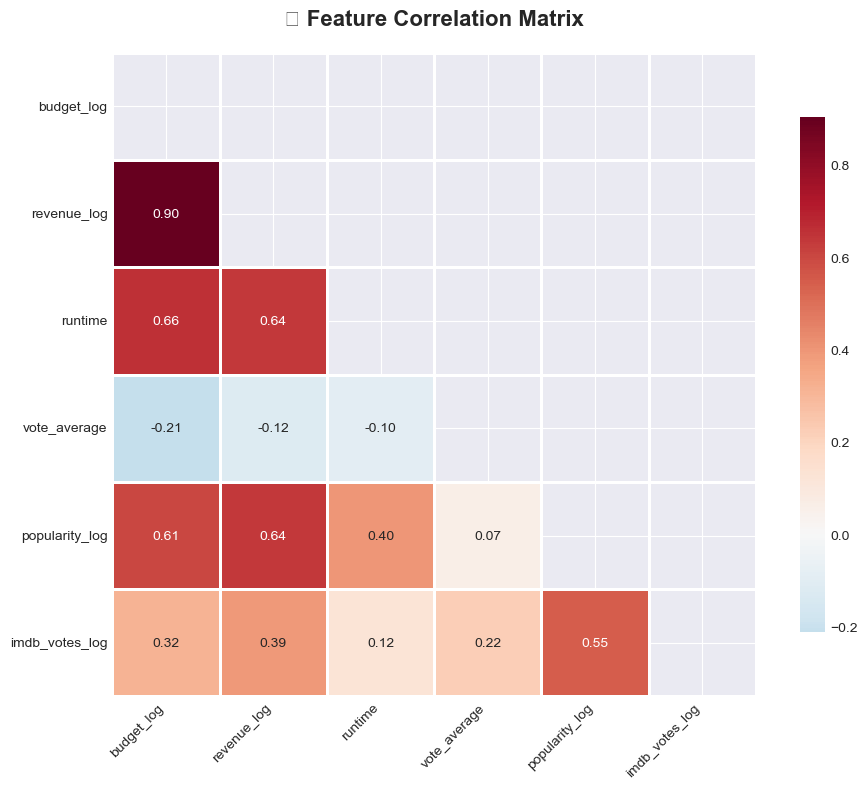

🔑 KEY CORRELATION INSIGHTS
🔥 Strongest Positive Relationship: revenue_log ↔ budget_log (0.90)

💰 Does Budget affect Quality? (Budget ↔ Rating)
   Correlation: -0.212
   👉 Insight: YES. Higher budgets correlate with better ratings.


In [ ]:
# ============================================
# 6.1 Correlation Heatmap
# ============================================

# 1. Select columns (Using Log versions for skewed data is more accurate!)
cols_to_correlate = [
    'budget_log', 
    'revenue_log', 
    'runtime',          # Keep raw, normally distributed enough
    'vote_average',     # Keep raw
    'popularity_log', 
    'imdb_votes_log'
]

# Filter to only include columns that actually exist in your dataframe
valid_cols = [c for c in cols_to_correlate if c in df.columns]

# 2. Calculate Correlation Matrix
corr_matrix = df[valid_cols].corr()

# 3. Visualize
plt.figure(figsize=(10, 8))

# Create a mask to hide the upper triangle (cleaner look, same data)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
    mask=mask,                # Hide upper triangle
    annot=True,               # Show numbers
    fmt=".2f",                # 2 decimal places
    cmap='RdBu_r',            # Red/Blue diverging colormap (standard for correlation)
    center=0,                 # Center white at 0
    square=True,              # Make cells square
    linewidths=1,             # Add grid lines
    linecolor='white',
    cbar_kws={"shrink": .8}   # Make color bar smaller
)

# Formatting
plt.title('📊 Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right') # Rotate labels if they overlap
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# ============================================
# Interpretation Helper
# ============================================
print("="*70)
print("🔑 KEY CORRELATION INSIGHTS")
print("="*70)

# Find strongest positive correlation
positive_corr = corr_matrix.where(np.triu(np.ones_like(corr_matrix, dtype=bool), k=1).astype(bool))
max_pos = positive_corr.unstack().dropna()
max_corr = max_pos.idxmax()
max_val = max_pos.max()

print(f"🔥 Strongest Positive Relationship: {max_corr[0]} ↔ {max_corr[1]} ({max_val:.2f})")

# Check Budget vs Rating specifically
if 'budget_log' in corr_matrix.columns and 'vote_average' in corr_matrix.columns:
    budget_rating_corr = corr_matrix.loc['budget_log', 'vote_average']
    print(f"\n💰 Does Budget affect Quality? (Budget ↔ Rating)")
    print(f"   Correlation: {budget_rating_corr:.3f}")
    if abs(budget_rating_corr) < 0.2:
        print("   👉 Insight: NO. Spending more money does not guarantee a better movie.")
    else:
        print("   👉 Insight: YES. Higher budgets correlate with better ratings.")

print("="*70)

<font size="3"><b>6.2 Genre Analysis </b></font>

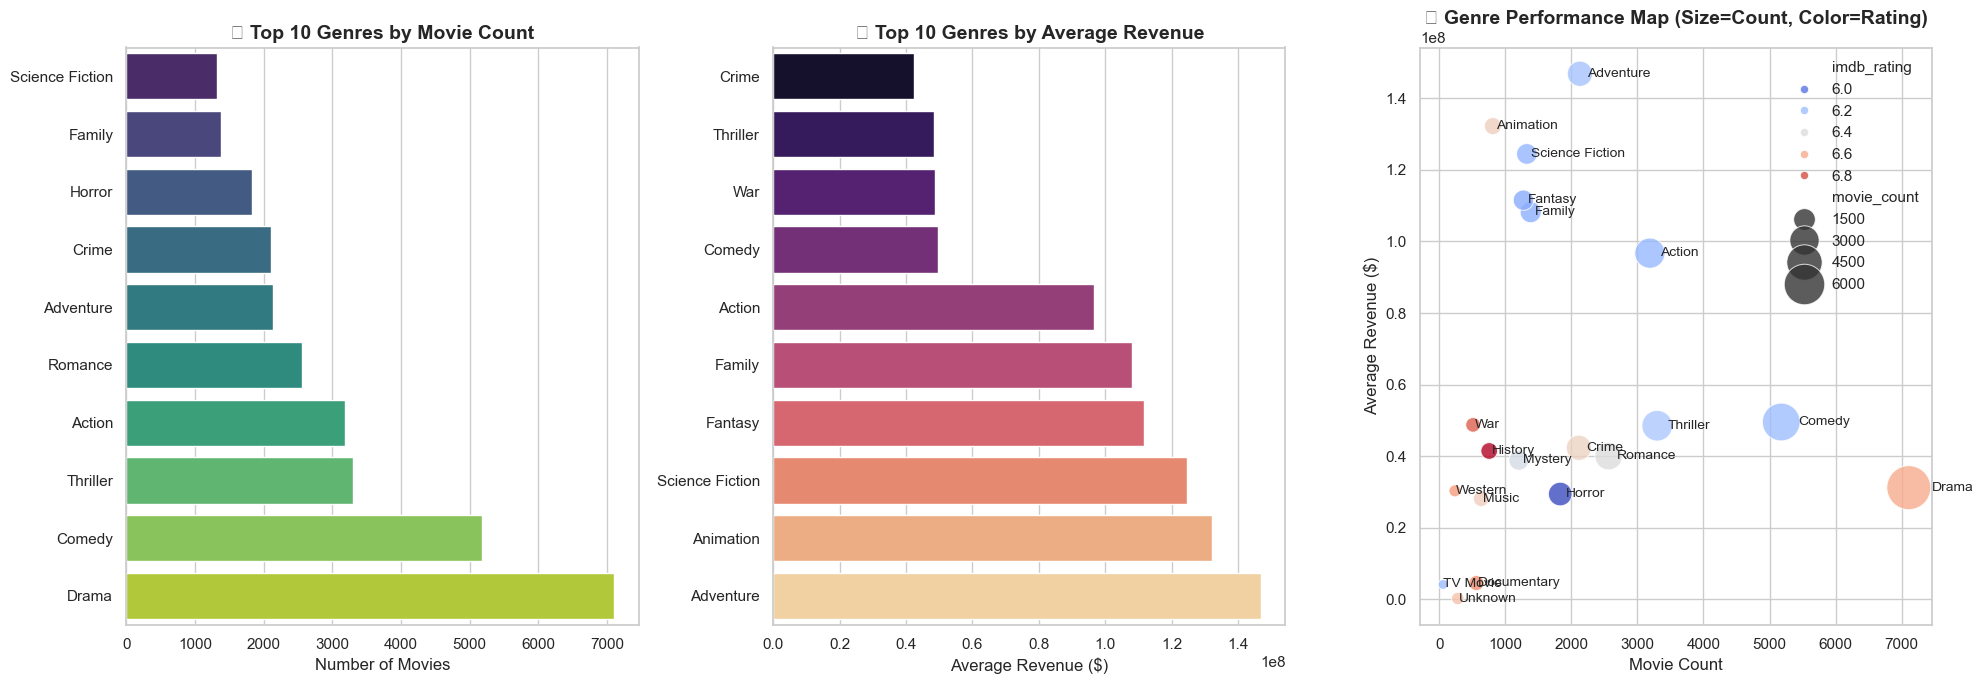

In [ ]:
# ============================================
# 6.2 Genre Analysis Visualization
# ============================================

# 1. Prepare the Data
# Ensure genres are split into lists
df['genres_list'] = df['genres'].apply(lambda x: [g.strip() for g in str(x).split(',')])

# Explode to get one row per genre per movie
genre_df = df.explode('genres_list')

# Filter out 'Unknown' or empty genres for cleaner charts
genre_df = genre_df[genre_df['genres_list'].str.len() > 1] 

# Aggregate statistics
genre_stats = genre_df.groupby('genres_list').agg({
    'revenue': 'mean',
    'imdb_rating': 'mean',
    'title': 'count'  # Count movies
}).rename(columns={'title': 'movie_count'}).sort_values('movie_count', ascending=False)

# ============================================
# VISUALIZATIONS
# ============================================

# Set style
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Chart 1: Most Popular Genres (Volume) ---
top_10_count = genre_stats.head(10).sort_values('movie_count', ascending=True)
sns.barplot(x=top_10_count['movie_count'], y=top_10_count.index, 
            palette='viridis', ax=axes[0])
axes[0].set_title('📊 Top 10 Genres by Movie Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Movies')
axes[0].set_ylabel('')

# --- Chart 2: Most Profitable Genres (Value) ---
# Sort by revenue to see what makes money, regardless of count
top_10_rev = genre_stats.sort_values('revenue', ascending=True).tail(10)
sns.barplot(x=top_10_rev['revenue'], y=top_10_rev.index, 
            palette='magma', ax=axes[1])
axes[1].set_title('💰 Top 10 Genres by Average Revenue', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Revenue ($)')
axes[1].set_ylabel('')

# --- Chart 3: Genre Performance Map (Multivariate) ---
# Plot all genres as a bubble chart
# X-axis = Count, Y-axis = Revenue, Color = Rating
top_20_stats = genre_stats.head(20)

scatter = sns.scatterplot(data=top_20_stats, 
                          x='movie_count', 
                          y='revenue', 
                          size='movie_count', 
                          sizes=(50, 1000), # Size of bubbles
                          hue='imdb_rating', 
                          palette='coolwarm',
                          alpha=0.8, ax=axes[2])

# Annotate the points with genre names
for i, row in top_20_stats.iterrows():
    axes[2].text(row['movie_count'] * 1.05, row['revenue'], i, 
                 fontsize=10, va='center')

axes[2].set_title('️ Genre Performance Map (Size=Count, Color=Rating)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Movie Count')
axes[2].set_ylabel('Average Revenue ($)')

plt.tight_layout()
plt.show()